In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from flax import nnx
from torchvision import transforms
from torchvision.datasets import MNIST

In [2]:
# Download MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: jnp.array(x.numpy(), dtype=jnp.float32)),
])

train_dataset = MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = MNIST(root="./data", train=False, download=True, transform=transform)

# Convert to JAX arrays
train_images = jnp.stack([x[0] for x in train_dataset])
train_labels = jnp.array([x[1] for x in train_dataset])
test_images = jnp.stack([x[0] for x in test_dataset])
test_labels = jnp.array([x[1] for x in test_dataset])

print(f"Train images shape: {train_images.shape}")
print(f"Train labels shape: {train_labels.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")

Train images shape: (60000, 1, 28, 28)
Train labels shape: (60000,)
Test images shape: (10000, 1, 28, 28)
Test labels shape: (10000,)


In [3]:
# Normalize and reshape images
train_images = train_images / 255.0
test_images = test_images / 255.0

# Flatten images from (N, 1, 28, 28) to (N, 784)
train_images = train_images.reshape(train_images.shape[0], -1)
test_images = test_images.reshape(test_images.shape[0], -1)


# One-hot encode labels
def one_hot(labels: jax.Array, num_classes:int=10) -> jax.Array:
    return jnp.array([jnp.eye(num_classes)[label] for label in labels])


train_labels = one_hot(train_labels)
test_labels = one_hot(test_labels)

print(f"Train images shape after flatten: {train_images.shape}")
print(f"Train labels shape after one-hot: {train_labels.shape}")

Train images shape after flatten: (60000, 784)
Train labels shape after one-hot: (60000, 10)


In [4]:
# Define the neural network model using Flax nnx
class MLP(nnx.Module):
    def __init__(
            self,
            input_dim: int,
            hidden_dim: int,
            output_dim: int,
            *,
            rngs: nnx.Rngs
    ) -> None:
        self.linear1 = nnx.Linear(input_dim, hidden_dim, rngs=rngs)
        self.linear2 = nnx.Linear(hidden_dim, output_dim, rngs=rngs)

    def __call__(self, x: jax.Array) -> jax.Array:
        x = jax.nn.relu(self.linear1(x))
        return self.linear2(x)

In [5]:
# Initialize model and optimizer
rngs = nnx.Rngs(42)
model = MLP(784, 128, 10, rngs=rngs)


# Define loss function
def loss_fn(
        model: nnx.Module,
        x: jax.Array,
        y: jax.Array
) -> jax.Array:
    logits = model(x)
    return optax.softmax_cross_entropy_with_integer_labels(
        logits,
        jnp.argmax(y, axis=1)
    ).mean()


# Define accuracy function
def accuracy_fn(model: nnx.Module, x: jax.Array, y: jax.Array) -> jax.Array:
    logits = model(x)
    predictions = jnp.argmax(logits, axis=1)
    targets = jnp.argmax(y, axis=1)
    return jnp.mean(predictions == targets)

In [6]:
# Create optimizer
adam = optax.adam(learning_rate=0.001)
optimizer = nnx.Optimizer(model, adam, wrt=nnx.Param)


# JIT compile the training and evaluation steps
def train_step(
        model: nnx.Module,
        x: jax.Array,
        y: jax.Array
) -> tuple[nnx.Param, optax.OptState, float]:
    loss, grads = nnx.value_and_grad(loss_fn)(model, x, y)
    optimizer.update(model, grads)
    return loss


def eval_step(
        model: nnx.Module,
        x: jax.Array,
        y: jax.Array
) -> tuple[jax.Array, jax.Array]:
    loss = loss_fn(model, x, y)
    acc = accuracy_fn(model, x, y)
    return loss, acc

In [9]:
# Training loop
batch_size = 64
num_epochs = 20

train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(num_epochs):
    # Shuffle training data
    rngs = nnx.Rngs(42 + epoch)
    indices = jnp.arange(len(train_images))
    shuffled_indices = jax.random.permutation(rngs(), indices)

    epoch_train_loss = 0.0
    epoch_train_acc = 0.0
    num_batches = 0

    for i in range(0, len(train_images), batch_size):
        batch_indices = shuffled_indices[i:i + batch_size]
        x_batch = train_images[batch_indices]
        y_batch = train_labels[batch_indices]

        batch_loss = train_step(model, x_batch, y_batch)
        batch_acc = accuracy_fn(model, x_batch, y_batch)

        epoch_train_loss += batch_loss
        epoch_train_acc += batch_acc
        num_batches += 1

    avg_train_loss = epoch_train_loss / num_batches
    avg_train_acc = epoch_train_acc / num_batches

    # Evaluate on test set
    test_loss, test_acc = eval_step(model, test_images, test_labels)

    train_losses.append(avg_train_loss)
    train_accuracies.append(avg_train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(
        f"Epoch {epoch + 1}/{num_epochs}: train_loss={avg_train_loss:.4f}, "
        f"train_acc={avg_train_acc:.4f}, "
        f"test_loss={test_loss:.4f}, "
        f"test_acc={test_acc:.4f}"
    )

Epoch 1/20: train_loss=0.2038, train_acc=0.9421, test_loss=0.2043, test_acc=0.9401
Epoch 2/20: train_loss=0.1990, train_acc=0.9432, test_loss=0.1999, test_acc=0.9415
Epoch 3/20: train_loss=0.1942, train_acc=0.9443, test_loss=0.1965, test_acc=0.9427
Epoch 4/20: train_loss=0.1892, train_acc=0.9461, test_loss=0.1918, test_acc=0.9442
Epoch 5/20: train_loss=0.1848, train_acc=0.9477, test_loss=0.1881, test_acc=0.9443
Epoch 6/20: train_loss=0.1805, train_acc=0.9490, test_loss=0.1845, test_acc=0.9465
Epoch 7/20: train_loss=0.1762, train_acc=0.9505, test_loss=0.1807, test_acc=0.9470
Epoch 8/20: train_loss=0.1722, train_acc=0.9511, test_loss=0.1766, test_acc=0.9494
Epoch 9/20: train_loss=0.1683, train_acc=0.9526, test_loss=0.1730, test_acc=0.9491
Epoch 10/20: train_loss=0.1644, train_acc=0.9535, test_loss=0.1692, test_acc=0.9510
Epoch 11/20: train_loss=0.1608, train_acc=0.9547, test_loss=0.1671, test_acc=0.9515
Epoch 12/20: train_loss=0.1570, train_acc=0.9561, test_loss=0.1634, test_acc=0.9513
E

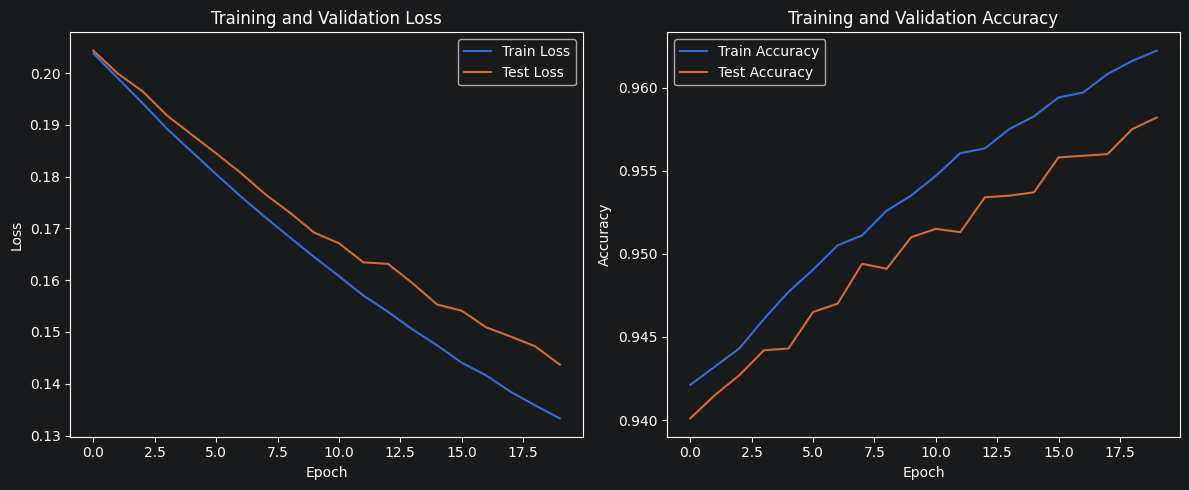

In [10]:
# Plot training and validation curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")

plt.tight_layout()
plt.show()

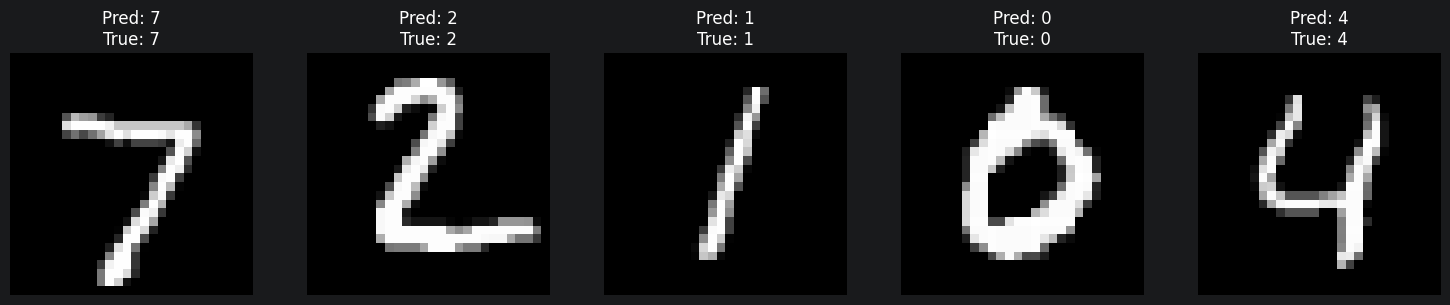

In [11]:
# Visualize some predictions
def show_predictions(
        model: nnx.Module,
        images: jax.Array,
        labels: jax.Array,
        num_samples: int = 5
) -> None:
    logits = model(images[:num_samples])
    predictions = jnp.argmax(logits, axis=1)
    true_labels = jnp.argmax(labels[:num_samples], axis=1)

    plt.figure(figsize=(15, 3))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(images[i].reshape(28, 28), cmap="gray")
        plt.title(f"Pred: {predictions[i]}\nTrue: {true_labels[i]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()


show_predictions(model, test_images, test_labels)

In [12]:
# Final evaluation
final_test_loss, final_test_acc = eval_step(model, test_images, test_labels)
print(f"Final Test Loss: {final_test_loss:.4f}")
print(f"Final Test Accuracy: {final_test_acc:.4f}")

Final Test Loss: 0.1437
Final Test Accuracy: 0.9582
